# TP 1 : IA & Santé - Diagnostic Cancer (Classification) 🩺
(CORRECTION DÉTAILLÉE)

**Objectif :** Prédire 'Bénin' ou 'Malin' et comprendre les métriques critiques en santé (Rappel, ROC).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

np.random.seed(42)

## 1. Chargement et Exploration

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame
X = data.data
y = data.target
print("Classes :", data.target_names) # 0 = Malignant, 1 = Benign
df.head()

Classes : ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 1.1 Analyse Exploratoire

Vérifions le type des données et s'il manque des valeurs.

In [3]:
print("Infos DataFrame :")
df.info()
print("\nStatistiques descriptives :")
display(df.describe())
print("\nValeurs manquantes :")
print(df.isnull().sum().sum())

Infos DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothne

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Valeurs manquantes :
0


### Visualisation des Données

#### A. Équilibre des classes

/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_28158/883399397.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


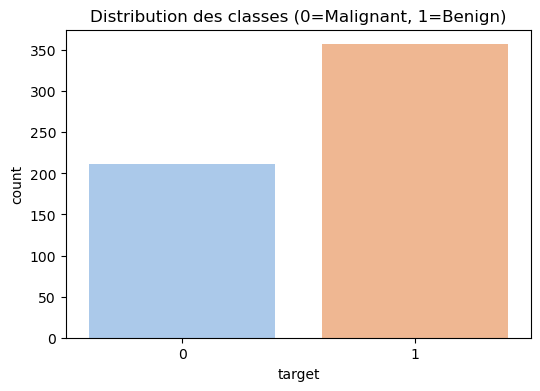

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='pastel')
plt.title("Distribution des classes (0=Malignant, 1=Benign)")
plt.show()

#### B. Corrélations

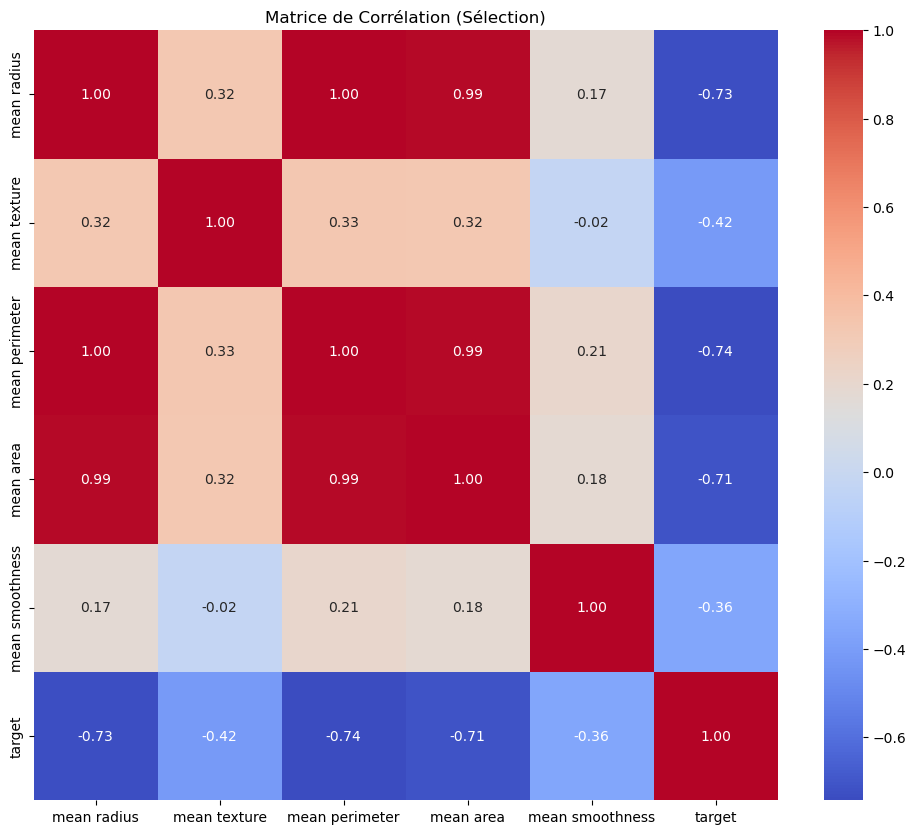

In [5]:
plt.figure(figsize=(12, 10))
# On ne prend que quelques colonnes pour la lisibilité
cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'target']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation (Sélection)")
plt.show()

#### C. Comparaison (Boxplots)

/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_28158/1252333820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='mean radius', data=df, palette='coolwarm')
/var/folders/pb/snzns2vx1v59ngzx14bljb640000gp/T/ipykernel_28158/1252333820.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='mean texture', data=df, palette='coolwarm')


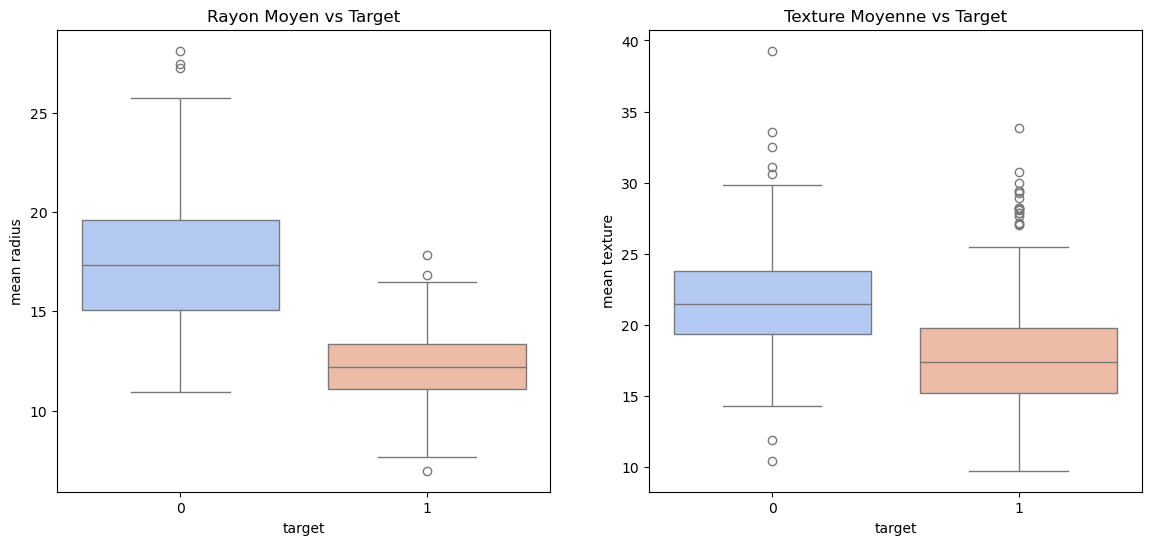

In [18]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='target', y='mean radius', data=df, palette='coolwarm')
plt.title("Rayon Moyen vs Target")

plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='mean texture', data=df, palette='coolwarm')
plt.title("Texture Moyenne vs Target")
plt.show()

### 💡 Explication Résultats
1.  **Classes** : On vérifie si on a assez de données pour les deux cas.
2.  **Corrélations** : Rayon, Périmètre et Aire sont très corrélés (logique). Ils sont aussi fortement corrélés négativement avec la Target.
3.  **Boxplots** : Les tumeurs malignes (0) ont clairement un rayon plus grand (médiane plus haute) que les bénignes (1). C'est un bon "discriminant".

## 2. Modélisation (KNN vs RF)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
print(f"KNN Accuracy: {knn.score(X_test_scaled, y_test):.4f}")
print(f"RF Accuracy: {rf.score(X_test_scaled, y_test):.4f}")

KNN Accuracy: 0.9474
RF Accuracy: 0.9649


### 💡 Pourquoi ces modèles ?
1.  **KNN** : Simple, sensible aux distances.
2.  **Random Forest** : Robuste, nécessite moins de pré-traitement.

In [9]:
y_test

204    1
70     0
131    0
431    1
540    1
      ..
486    1
75     0
249    1
238    1
265    0
Name: target, Length: 114, dtype: int64

## 3. Analyse Avancée : Courbe ROC

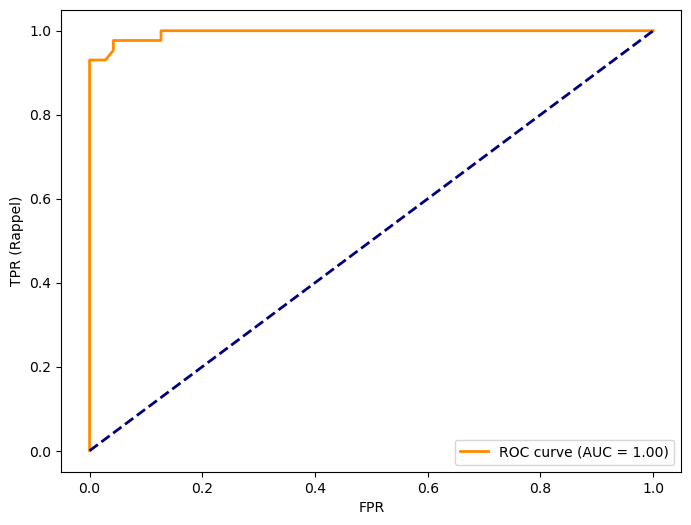

In [ ]:
y_test_binary = (y_test == 0).astype(int) 
y_probs_cancer = rf.predict_proba(X_test_scaled)[:, 0] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs_cancer)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR (Rappel)')
plt.legend(loc="lower right")
plt.show()

### 💡 Comprendre la ROC et l'AUC
L'AUC > 0.95 indique un excellent modèle.

## 4. Explicabilité : Pourquoi ce diagnostic ?

### A. Importance des caractéristiques (Random Forest)
Le modèle Random Forest peut nous dire quelles colonnes ont le plus pesé dans sa décision.

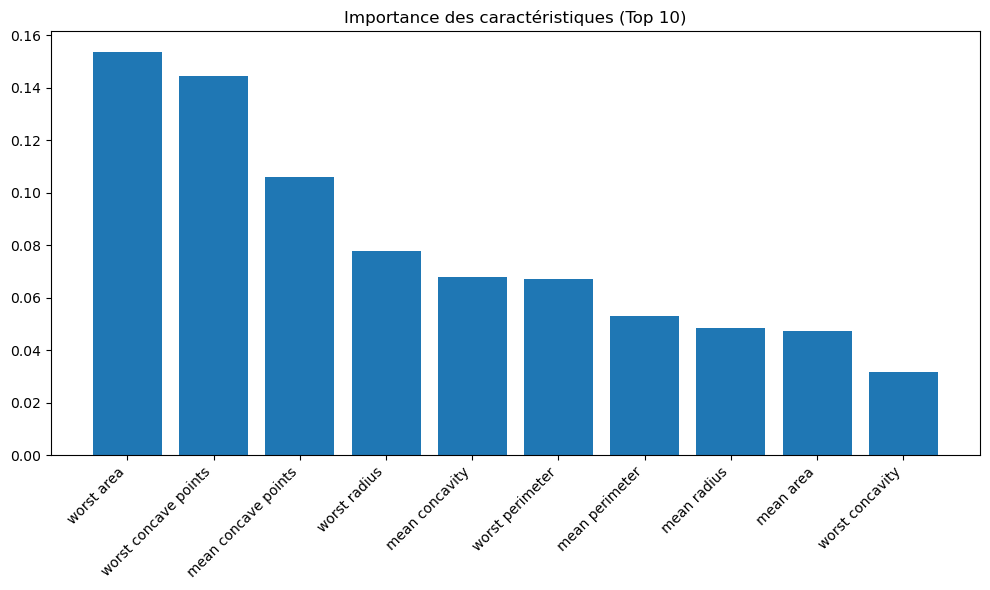

In [11]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

plt.figure(figsize=(10, 6))
plt.title("Importance des caractéristiques (Top 10)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), features[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 💡 Interprétation
On voit souvent que le **'worst perimeter'**, **'mean concave points'** ou **'worst radius'** sont déterminants.
Cela valide médicalement le modèle : la taille et l'irrégularité de la tumeur sont bien des signes de gravité.

### B. Analyse d'une erreur (Faux Négatif)
Regardons un patient malade (Classe 0) que le modèle a cru sain (Classé 1). C'est le cas le plus dangereux.

Patient Index (Test Set) : 20
Vraie Classe : Malade (Malignant)
Prédiction IA : Sain (Benign) -> DANGER !


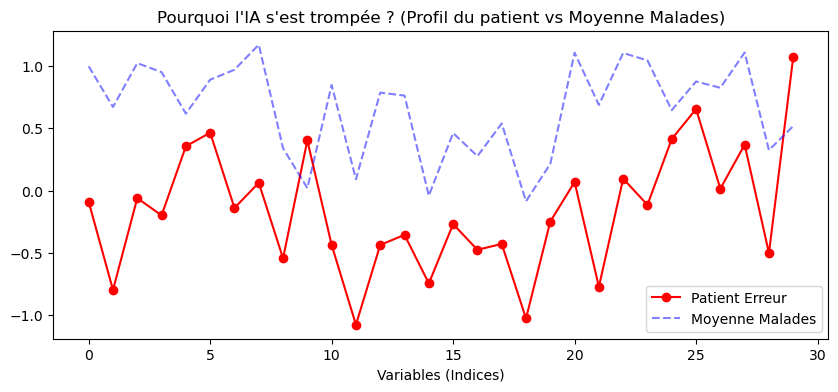

In [12]:
y_pred = rf.predict(X_test_scaled)
# Trouver les indices des Faux Négatifs (Vrai=0, Prédit=1)
# Attention : Rappel y=0 (Malignant), y=1 (Benign).
# Faux Négatif médical = Malade (0) prédit Sain (1).
errors = np.where((y_test == 0) & (y_pred == 1))[0]

if len(errors) > 0:
    idx = errors[0] # Prenons le premier
    print(f"Patient Index (Test Set) : {idx}")
    print("Vraie Classe : Malade (Malignant)")
    print("Prédiction IA : Sain (Benign) -> DANGER !")
    
    # Comparons ses valeurs à la moyenne des Malades
    patient_vals = X_test_scaled[idx]
    mean_malignant = np.mean(X_test_scaled[y_test==0], axis=0)
    
    plt.figure(figsize=(10, 4))
    plt.plot(patient_vals, label='Patient Erreur', color='red', marker='o')
    plt.plot(mean_malignant, label='Moyenne Malades', color='blue', linestyle='--', alpha=0.5)
    plt.legend()
    plt.title("Pourquoi l'IA s'est trompée ? (Profil du patient vs Moyenne Malades)")
    plt.xlabel("Variables (Indices)")
    plt.show()
else:
    print("Bravo ! Aucun Faux Négatif trouvé avec ce Random State. Le modèle est très sûr.")